In [6]:
import requests
import pandas as pd
data = requests.get("https://eodhd.com/api/intraday/AAPL.US?interval=5m&api_token=667822cc36e777.79338265&fmt=json").json()
data = pd.DataFrame(data)
data.to_json('test_data3.json')

data = requests.get("https://eodhd.com/api/intraday/TSLA.US?interval=5m&api_token=667822cc36e777.79338265&fmt=json").json()
data = pd.DataFrame(data)
data.to_json('test_data4.json')

In [3]:
import requests
import pandas as pd
data1 = pd.read_json('test_data1.json')
data2 = pd.read_json('test_data2.json')
data1

,date,open,high,low,close,adjusted_close,volume
0,2010-06-29,18.9999,24.9999,17.5401,23.8899,1.5927,281749173
1,2010-06-30,25.7901,30.4191,23.3001,23.8299,1.5887,257915884
2,2010-07-01,24.9999,25.9200,20.2701,21.9600,1.4640,123447940
3,2010-07-02,23.0001,23.1000,18.7101,19.2000,1.2800,77127102
4,2010-07-06,20.0001,20.0001,15.8301,16.1100,1.0740,103189435
...,...,...,...,...,...,...,...
3596,2024-10-11,220.1300,223.3400,214.3800,217.8000,217.8000,142628891
3597,2024-10-14,220.1300,221.9100,213.7400,219.1600,219.1600,86291922
3598,2024-10-15,220.0100,224.2600,217.1200,219.5700,219.5700,62988793
3599,2024-10-16,221.4000,222.8199,218.9300,221.3300,221.3300,49632820


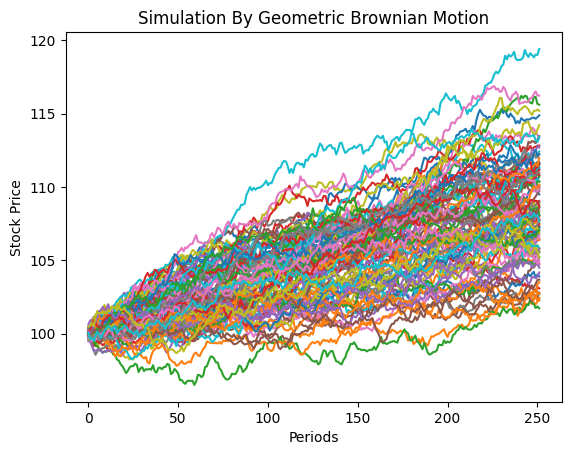

In [2]:
from Backtest.lib.simulation import plot_GBM
plot_GBM(mu=0.2,sigma=0.5, M=100)

In [1]:
from Backtest.lib.preprocessing import data_preprocess
import pandas as pd

data1 = pd.read_json('test_data1.json')
data2 = pd.read_json('test_data2.json')
data = {
    'TSLA': data1, 
    'AAPL': data2,
}
df = data_preprocess(data)
df

,date,open_TSLA,high_TSLA,low_TSLA,close_TSLA,adjusted_close_TSLA,volume_TSLA,open_AAPL,high_AAPL,low_AAPL,close_AAPL,adjusted_close_AAPL,volume_AAPL
7453,2010-06-29,18.9999,24.9999,17.5401,23.8899,1.5927,281749173.0,264.1212,264.3900,254.2988,256.1692,7.7261,1133344800
7454,2010-06-30,25.7901,30.4191,23.3001,23.8299,1.5887,257915884.0,256.7096,257.9696,250.0092,251.5296,7.5862,739452000
7455,2010-07-01,24.9999,25.9200,20.2701,21.9600,1.4640,123447940.0,254.2988,254.8000,243.2192,248.4804,7.4942,1022896000
7456,2010-07-02,23.0001,23.1000,18.7101,19.2000,1.2800,77127102.0,250.4908,250.9304,243.1996,246.9404,7.4478,693842800
7457,2010-07-06,20.0001,20.0001,15.8301,16.1100,1.0740,103189435.0,251.0004,252.8008,246.1592,248.6288,7.4987,615235600
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11049,2024-10-11,220.1300,223.3400,214.3800,217.8000,217.8000,142628891.0,229.3000,229.4100,227.3400,227.5500,227.5500,31759200
11050,2024-10-14,220.1300,221.9100,213.7400,219.1600,219.1600,86291922.0,228.7000,231.7300,228.6000,231.3000,231.3000,39882100
11051,2024-10-15,220.0100,224.2600,217.1200,219.5700,219.5700,62988793.0,233.6100,237.4900,232.3700,233.8500,233.8500,64751400
11052,2024-10-16,221.4000,222.8199,218.9300,221.3300,221.3300,49632820.0,231.6000,232.1200,229.8400,231.7800,231.7800,34082200


In [1]:
from strategy import Strategy
from backtest import Backtest
import pandas as pd
data = pd.read_json('test_data1.json')
data['dreturn'] = (data['close'] - data['open'])/data['open']
class DummyStrat(Strategy):
    def __init__(self):
        def signal(dreturn):
            if dreturn > 1:
                return 1
            if dreturn < -1:
                return -1
            return 0
        self.signal_func= signal
    
    def iter(self, data):
        curr_signal = self.signal_func(data['dreturn'])
        units = self.account.buying_power // 2
        if curr_signal == 1:
            '''
            We long equity
            '''
            self.create_position(data['timestamp'], data['symbol'], units, data['close'])
        elif curr_signal == -1:
            '''
            We short equity
            '''
            self.create_position(data['timestamp'], data['symbol'], -units, data['close'])
        elif curr_signal == 0:
            '''
            We close all positions
            '''
            self.close_all_positions(data['timestamp'])
        


In [3]:
from strategy import Strategy
from backtest import Backtest
from lib.preprocessing import df_to_dict, data_preprocess
import pandas as pd
import numpy as np

class DummyStrat():
    def __init__(self):
        self.trader = Strategy()
        self.account = self.trader.account
        def signal(dreturn):
            if dreturn > 2:
                return 1
            if dreturn < -2:
                return -1
            return 0
        self.signal_func= signal
    
    def iter(self, data):
        curr_signal = self.signal_func(data['dreturn_AAPL'])
        units = (self.account.buying_power // 2)/data['close_AAPL']
        curr_portfolio = self.account.get_curr_portfolio()
        open_positions = [pos for pos in curr_portfolio.positions if pos.symbol == 'AAPL' and pos.status == 'open']
        if curr_signal == 1:
            '''
            We long equity
            '''
            if len(open_positions) == 0:
                self.trader.create_position(data['timestamp_AAPL'], 'AAPL', units, data['close_AAPL'])
        
        elif curr_signal == -1:
            '''
            We short equity
            '''
            if len(open_positions) == 0:
                self.trader.create_position(data['timestamp_AAPL'], 'AAPL', -units, data['close_AAPL'])

        elif curr_signal == 0 and len(open_positions) > 0:
            '''
            We close position
            '''
            self.trader.close_position(data['timestamp_AAPL'], 'AAPL', data['close_AAPL'])
class MultiTickerDummyStrat():
    def __init__(self):
        self.trader = Strategy()
        self.account = self.trader.account
        def signal(dreturn):
            if dreturn > 2:
                return 1
            if dreturn < -2:
                return -1
            return 0
        self.signal_func= signal
    
    def iter(self, data, ticker):
        curr_signal = self.signal_func(data['dreturn_' + ticker])
        units = (self.account.buying_power // 3)/data['close_' + ticker]
        curr_portfolio = self.account.get_curr_portfolio()
        open_positions = [pos for pos in curr_portfolio.positions if pos.symbol == ticker and pos.status == 'open']
        if curr_signal == 1:
            '''
            We long equity
            '''
            if len(open_positions) == 0:
                self.trader.create_position(data['timestamp'], ticker, units, data['close_'+ticker])
        
        elif curr_signal == -1:
            '''
            We short equity
            '''
            if len(open_positions) == 0:
                self.trader.create_position(data['timestamp'], ticker, -units, data['close_'+ticker])

        elif curr_signal == 0 and len(open_positions) > 0:
            '''
            We close position
            '''
            self.trader.close_position(data['timestamp'], ticker, data['close_'+ticker])

data = pd.read_json('test_data1.json')
data2 = pd.read_json('test_data2.json')
data['dreturn'] = ((data['close'] - data['open'])/data['open']) * 100
data2['dreturn'] = ((data2['close'] - data2['open'])/data2['open']) * 100
data.rename({'date': 'timestamp'}, axis=1, inplace=True)
data2.rename({'date': 'timestamp'}, axis=1, inplace=True)
data = df_to_dict([data, data2], ['AAPL', 'TSLA'])
data = data_preprocess(data)
data = data.iloc[-100:]
bt = Backtest(MultiTickerDummyStrat, data, ['AAPL', 'TSLA'])
bt.run(verbose=1)
bt.plot()

Trading 100 instances...


In [1]:
bt.performance()

NameError: name 'bt' is not defined